In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

path = "/kaggle/input/competitions/house-prices-advanced-regression-techniques/"
df = pd.read_csv(path + "train.csv")
test = pd.read_csv(path + "test.csv")

print(df.shape)
df[["GrLivArea", "BedroomAbvGr", "FullBath", "HalfBath", "SalePrice"]].describe()

(1460, 81)


,GrLivArea,BedroomAbvGr,FullBath,HalfBath,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,1515.463699,2.866438,1.565068,0.382877,180921.195890
std,525.480383,0.815778,0.550916,0.502885,79442.502883
min,334.000000,0.000000,0.000000,0.000000,34900.000000
25%,1129.500000,2.000000,1.000000,0.000000,129975.000000
50%,1464.000000,3.000000,2.000000,0.000000,163000.000000
75%,1776.750000,3.000000,2.000000,1.000000,214000.000000
max,5642.000000,8.000000,3.000000,2.000000,755000.000000


In [5]:
def prepare(data):
    data = data.copy()
    for c in ["BsmtFullBath", "BsmtHalfBath"]:
        data[c] = data[c].fillna(0)
    data["TotalBath"] = (data["FullBath"] + 0.5 * data["HalfBath"]
                         + data["BsmtFullBath"] + 0.5 * data["BsmtHalfBath"])
    return data

df = prepare(df)
test = prepare(test)

features = ["GrLivArea", "BedroomAbvGr", "TotalBath"]
X = df[features]
y = df["SalePrice"]

print(X.head())
print("Valeurs manquantes :", X.isnull().sum().sum())

   GrLivArea  BedroomAbvGr  TotalBath
0       1710             3        3.5
1       1262             3        2.5
2       1786             3        3.5
3       1717             3        2.0
4       2198             4        3.5
Valeurs manquantes : 0


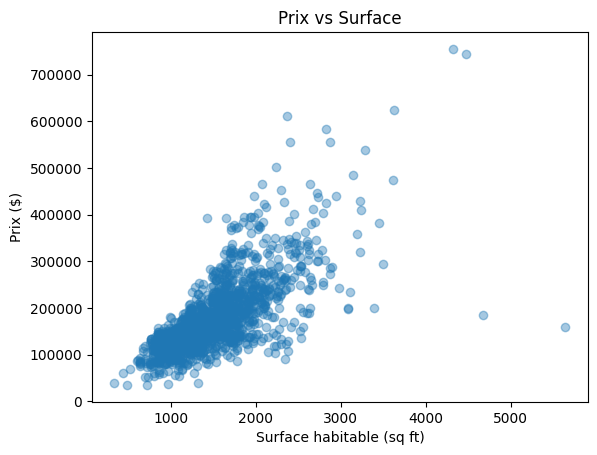

In [6]:
plt.scatter(df["GrLivArea"], df["SalePrice"], alpha=0.4)
plt.xlabel("Surface habitable (sq ft)")
plt.ylabel("Prix ($)")
plt.title("Prix vs Surface")
plt.show()

In [7]:
print("Avant :", df.shape)
df = df[~((df["GrLivArea"] > 4000) & (df["SalePrice"] < 300000))]
print("Après :", df.shape)

X = df[features]
y = df["SalePrice"]

Avant : (1460, 82)
Après : (1458, 82)


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept :", round(model.intercept_, 2))
for f, c in zip(features, model.coef_):
    print(f, ":", round(c, 2))

Intercept : 26342.06
GrLivArea : 120.97
BedroomAbvGr : -30038.83
TotalBath : 26254.97


RMSE : 46935.16
R²   : 0.601


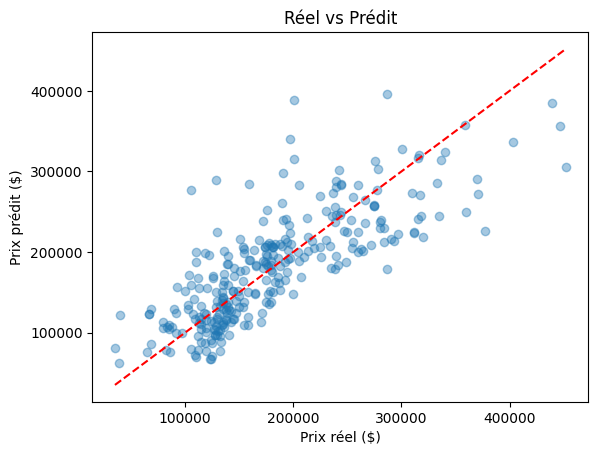

In [9]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_val)
print("RMSE :", round(np.sqrt(mean_squared_error(y_val, y_pred)), 2))
print("R²   :", round(r2_score(y_val, y_pred), 3))

plt.scatter(y_val, y_pred, alpha=0.4)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--")
plt.xlabel("Prix réel ($)")
plt.ylabel("Prix prédit ($)")
plt.title("Réel vs Prédit")
plt.show()

In [10]:
test_pred = model.predict(test[features])

submission = pd.DataFrame({"Id": test["Id"], "SalePrice": test_pred})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print(submission.shape)

     Id      SalePrice
0  1461  100905.430757
1  1462  136372.618272
2  1463  198917.567372
3  1464  195893.402833
4  1465  173611.572708
(1459, 2)


## Conclusion
- Modèle : Régression linéaire multiple
- Variables : surface habitable (GrLivArea), nombre de chambres (BedroomAbvGr), nombre total de salles de bain (TotalBath)
- Résultats sur l'ensemble de validation : **R² = 0.60**, **RMSE ≈ 46 935 $**
- Le modèle capte bien la tendance générale mais sous-estime les maisons les plus chères.
- Amélioration possible : ajouter d'autres variables (qualité, quartier, année de construction) ou prédire le log du prix.